# DeepSeek-V3 MoE Kernel DAG — B200 GPU

Visualization of the computational DAG from `kernel_ref.py`.

**Legend:**
- Green = graph input | Yellow = graph output | Blue = intermediate
- Op boxes color-coded by phase
- Dimensions use: T=tokens, H=7168, I=2048, E_local=32, E_global=256, BLOCK=128

In [1]:
import graphviz
from IPython.display import display

## B200 GPU Placeholder Parameters

| Parameter | Value | Notes |
|-----------|-------|-------|
| HBM Bandwidth | 8 TB/s | B200 HBM3e |
| L2 Cache | 128 MB | Placeholder |
| SRAM per SM | 256 KB | Placeholder |
| FP8 Tensor Core TFLOPS | 4500 | Placeholder |
| BF16 Tensor Core TFLOPS | 2250 | Placeholder |
| SMs | 192 | Placeholder |

In [2]:
# B200 GPU placeholder parameters
B200 = {
    'hbm_bandwidth_TB_s': 8.0,
    'l2_cache_MB': 128,
    'sram_per_sm_KB': 256,
    'num_sms': 192,
    'fp8_tflops': 4500,
    'bf16_tflops': 2250,
    'fp32_tflops': 1125,
}

# Kernel geometry
T = 4096  # placeholder token count
H = 7168
I = 2048
E_local = 32
E_global = 256
BLOCK = 128
TOP_K = 8
N_GROUP = 8
TOPK_GROUP = 4

---
## Full Kernel DAG

---
## FP8 Block-Scale Dequantization — Hidden States Detail

Zoomed-in DAG for `A = hidden_states_fp8 * scale_expanded` showing every base operation.

**Block geometry:** H=7168, BLOCK=128 → 56 scale blocks per token.
Scale layout `[56, T]` is transposed so each token's 56 scales align with its 56 × 128 hidden blocks.

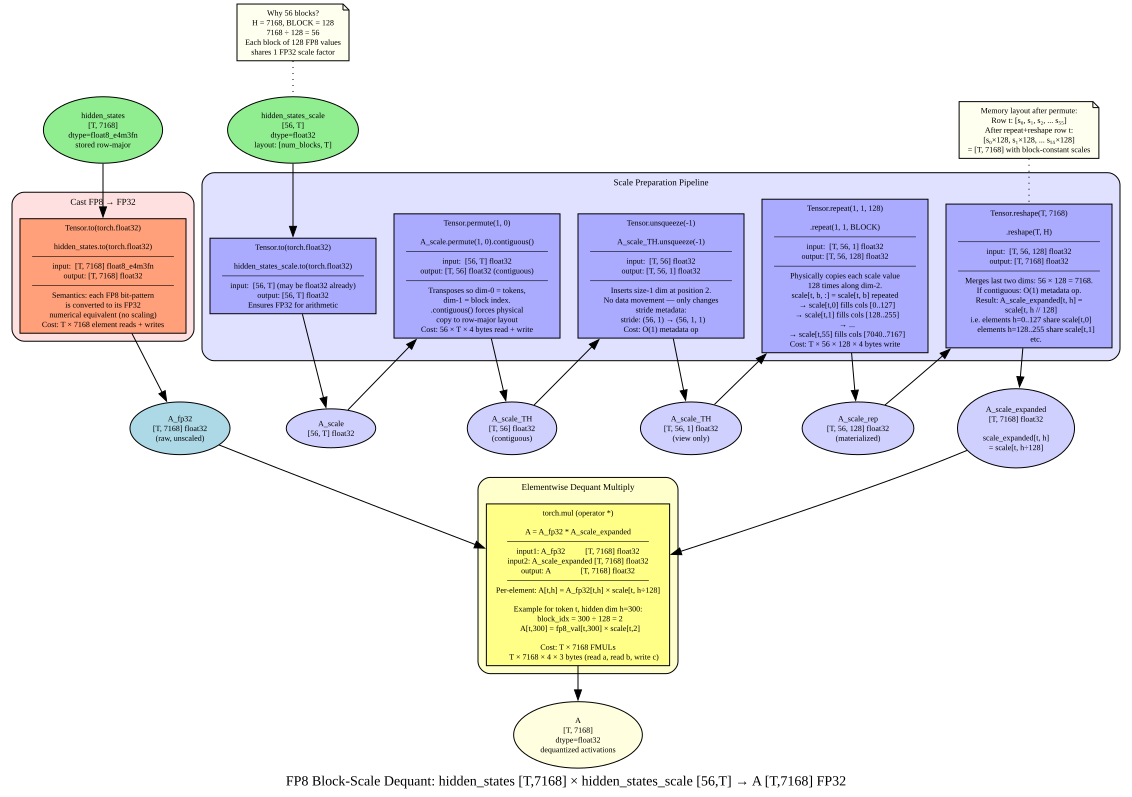

In [3]:
dq = graphviz.Digraph('Dequant_HiddenStates', format='svg')
dq.attr(rankdir='TB',
        label='FP8 Block-Scale Dequant: hidden_states [T,7168] × hidden_states_scale [56,T] → A [T,7168] FP32',
        fontsize='14', compound='true')
dq.attr('node', fontsize='8')
dq.attr('edge', fontsize='7')

# ── Inputs ──
dq.node('hs', 'hidden_states\n[T, 7168]\ndtype=float8_e4m3fn\nstored row-major', shape='ellipse', style='filled', fillcolor='lightgreen')
dq.node('hs_scale', 'hidden_states_scale\n[56, T]\ndtype=float32\nlayout: [num_blocks, T]', shape='ellipse', style='filled', fillcolor='lightgreen')

# ── Output ──
dq.node('A', 'A\n[T, 7168]\ndtype=float32\ndequantized activations', shape='ellipse', style='filled', fillcolor='lightyellow')

# ════════════════════════════════════════
# LEFT BRANCH: hidden_states → FP32
# ════════════════════════════════════════
with dq.subgraph(name='cluster_cast') as c:
    c.attr(label='Cast FP8 → FP32', style='rounded,filled', fillcolor='#FFE0E0', fontsize='9')

    c.node('cast_fp32', 'Tensor.to(torch.float32)\n\nhidden_states.to(torch.float32)\n'
           '─────────────────────────\n'
           'input:  [T, 7168] float8_e4m3fn\n'
           'output: [T, 7168] float32\n'
           '─────────────────────────\n'
           'Semantics: each FP8 bit-pattern\n'
           'is converted to its FP32\n'
           'numerical equivalent (no scaling)\n'
           'Cost: T × 7168 element reads + writes',
           shape='box', style='filled', fillcolor='lightsalmon')

dq.node('A_fp32', 'A_fp32\n[T, 7168] float32\n(raw, unscaled)',
        shape='ellipse', style='filled', fillcolor='lightblue')

dq.edge('hs', 'cast_fp32')
dq.edge('cast_fp32', 'A_fp32')

# ════════════════════════════════════════
# RIGHT BRANCH: scale → expanded [T, 7168]
# ════════════════════════════════════════
with dq.subgraph(name='cluster_scale_prep') as c:
    c.attr(label='Scale Preparation Pipeline', style='rounded,filled', fillcolor='#E0E0FF', fontsize='9')

    # Step 1: cast scale to FP32 (may already be FP32, but ref does .to(float32))
    c.node('cast_scale', 'Tensor.to(torch.float32)\n\nhidden_states_scale.to(torch.float32)\n'
           '─────────────────────────\n'
           'input:  [56, T] (may be float32 already)\n'
           'output: [56, T] float32\n'
           'Ensures FP32 for arithmetic',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 2: permute
    c.node('permute', 'Tensor.permute(1, 0)\n\nA_scale.permute(1, 0).contiguous()\n'
           '─────────────────────────\n'
           'input:  [56, T] float32\n'
           'output: [T, 56] float32 (contiguous)\n'
           '─────────────────────────\n'
           'Transposes so dim-0 = tokens,\n'
           'dim-1 = block index.\n'
           '.contiguous() forces physical\n'
           'copy to row-major layout\n'
           'Cost: 56 × T × 4 bytes read + write',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 3: unsqueeze
    c.node('unsqueeze', 'Tensor.unsqueeze(-1)\n\nA_scale_TH.unsqueeze(-1)\n'
           '─────────────────────────\n'
           'input:  [T, 56] float32\n'
           'output: [T, 56, 1] float32\n'
           '─────────────────────────\n'
           'Inserts size-1 dim at position 2.\n'
           'No data movement — only changes\n'
           'stride metadata:\n'
           '  stride: (56, 1) → (56, 1, 1)\n'
           'Cost: O(1) metadata op',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 4: repeat
    c.node('repeat', 'Tensor.repeat(1, 1, 128)\n\n.repeat(1, 1, BLOCK)\n'
           '─────────────────────────\n'
           'input:  [T, 56, 1] float32\n'
           'output: [T, 56, 128] float32\n'
           '─────────────────────────\n'
           'Physically copies each scale value\n'
           '128 times along dim-2.\n'
           'scale[t, b, :] = scale[t, b] repeated\n'
           '  → scale[t,0] fills cols [0..127]\n'
           '  → scale[t,1] fills cols [128..255]\n'
           '  → ...\n'
           '  → scale[t,55] fills cols [7040..7167]\n'
           'Cost: T × 56 × 128 × 4 bytes write',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 5: reshape
    c.node('reshape', 'Tensor.reshape(T, 7168)\n\n.reshape(T, H)\n'
           '─────────────────────────\n'
           'input:  [T, 56, 128] float32\n'
           'output: [T, 7168] float32\n'
           '─────────────────────────\n'
           'Merges last two dims: 56 × 128 = 7168.\n'
           'If contiguous: O(1) metadata op.\n'
           'Result: A_scale_expanded[t, h] =\n'
           '  scale[t, h // 128]\n'
           '  i.e. elements h=0..127 share scale[t,0]\n'
           '       elements h=128..255 share scale[t,1]\n'
           '       etc.',
           shape='box', style='filled', fillcolor='#AAAAFF')

# Scale intermediates
dq.node('s_fp32', 'A_scale\n[56, T] float32', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_TH', 'A_scale_TH\n[T, 56] float32\n(contiguous)', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_uns', 'A_scale_TH\n[T, 56, 1] float32\n(view only)', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_rep', 'A_scale_rep\n[T, 56, 128] float32\n(materialized)', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_exp', 'A_scale_expanded\n[T, 7168] float32\n\nscale_expanded[t, h]\n= scale[t, h÷128]',
        shape='ellipse', style='filled', fillcolor='#D0D0FF')

# Scale edges
dq.edge('hs_scale', 'cast_scale')
dq.edge('cast_scale', 's_fp32')
dq.edge('s_fp32', 'permute')
dq.edge('permute', 's_TH')
dq.edge('s_TH', 'unsqueeze')
dq.edge('unsqueeze', 's_uns')
dq.edge('s_uns', 'repeat')
dq.edge('repeat', 's_rep')
dq.edge('s_rep', 'reshape')
dq.edge('reshape', 's_exp')

# ════════════════════════════════════════
# FINAL: Elementwise Multiply
# ════════════════════════════════════════
with dq.subgraph(name='cluster_mul') as c:
    c.attr(label='Elementwise Dequant Multiply', style='rounded,filled', fillcolor='#FFFFCC', fontsize='9')

    c.node('mul', 'torch.mul (operator *)\n\nA = A_fp32 * A_scale_expanded\n'
           '─────────────────────────\n'
           'input1: A_fp32          [T, 7168] float32\n'
           'input2: A_scale_expanded [T, 7168] float32\n'
           'output: A               [T, 7168] float32\n'
           '─────────────────────────\n'
           'Per-element: A[t,h] = A_fp32[t,h] × scale[t, h÷128]\n'
           '\n'
           'Example for token t, hidden dim h=300:\n'
           '  block_idx = 300 ÷ 128 = 2\n'
           '  A[t,300] = fp8_val[t,300] × scale[t,2]\n'
           '\n'
           'Cost: T × 7168 FMULs\n'
           '      T × 7168 × 4 × 3 bytes (read a, read b, write c)',
           shape='box', style='filled', fillcolor='#FFFF88')

dq.edge('A_fp32', 'mul')
dq.edge('s_exp', 'mul')
dq.edge('mul', 'A')

# ════════════════════════════════════════
# Annotations
# ════════════════════════════════════════
dq.node('note1',
        'Why 56 blocks?\n'
        'H = 7168, BLOCK = 128\n'
        '7168 ÷ 128 = 56\n'
        'Each block of 128 FP8 values\n'
        'shares 1 FP32 scale factor',
        shape='note', style='filled', fillcolor='#FFFFF0', fontsize='8')

dq.node('note2',
        'Memory layout after permute:\n'
        'Row t: [s₀, s₁, s₂, ... s₅₅]\n'
        'After repeat+reshape row t:\n'
        '[s₀×128, s₁×128, ... s₅₅×128]\n'
        '= [T, 7168] with block-constant scales',
        shape='note', style='filled', fillcolor='#FFFFF0', fontsize='8')

dq.edge('note1', 'hs_scale', style='dotted', arrowhead='none')
dq.edge('note2', 'reshape', style='dotted', arrowhead='none')

display(dq)

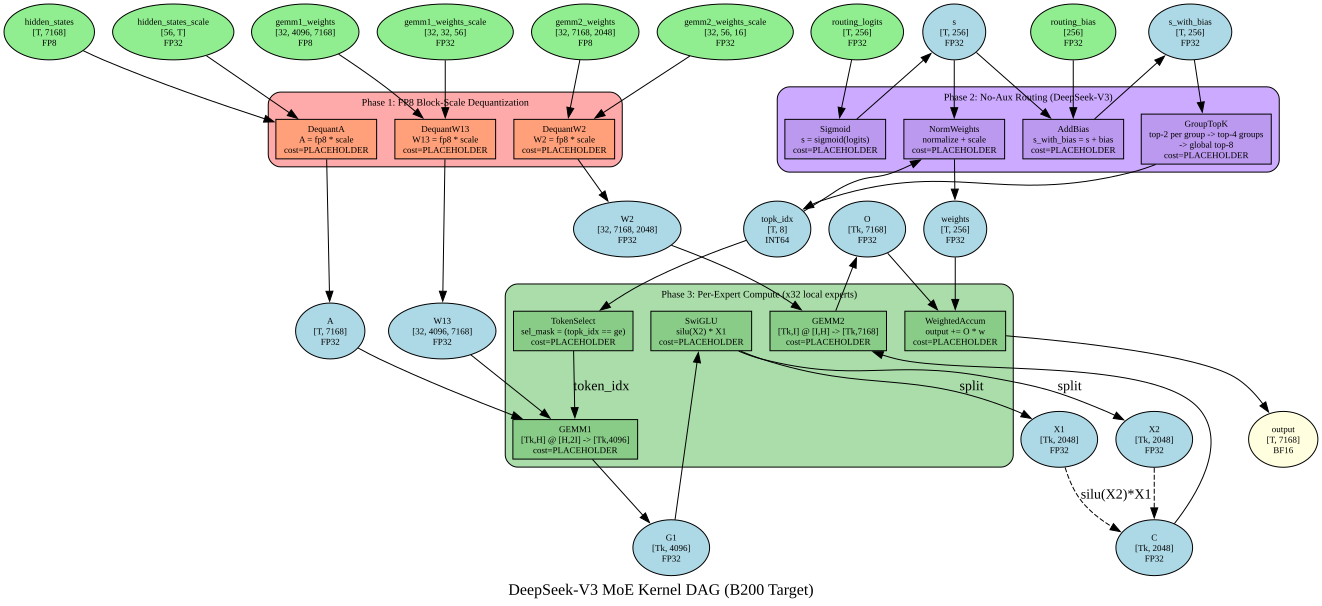

In [4]:
dot = graphviz.Digraph('MoE_Kernel_DAG', format='svg')
dot.attr(rankdir='TB', label='DeepSeek-V3 MoE Kernel DAG (B200 Target)', fontsize='16', compound='true')
dot.attr('node', fontsize='9')

# === Input Tensors (green) ===
inputs = {
    'routing_logits':      f'[T, 256]\nFP32',
    'routing_bias':        f'[256]\nFP32',
    'hidden_states':       f'[T, 7168]\nFP8',
    'hidden_states_scale': f'[56, T]\nFP32',
    'gemm1_weights':       f'[32, 4096, 7168]\nFP8',
    'gemm1_weights_scale': f'[32, 32, 56]\nFP32',
    'gemm2_weights':       f'[32, 7168, 2048]\nFP8',
    'gemm2_weights_scale': f'[32, 56, 16]\nFP32',
}
for name, shape in inputs.items():
    dot.node(name, f'{name}\n{shape}', shape='ellipse', style='filled', fillcolor='lightgreen')

# === Output Tensor (yellow) ===
dot.node('output', f'output\n[T, 7168]\nBF16', shape='ellipse', style='filled', fillcolor='lightyellow')

# === Intermediate Tensors (blue) ===
intermediates = {
    'A':          f'[T, 7168]\nFP32',
    'W13':        f'[32, 4096, 7168]\nFP32',
    'W2':         f'[32, 7168, 2048]\nFP32',
    's':          f'[T, 256]\nFP32',
    's_with_bias':f'[T, 256]\nFP32',
    'topk_idx':   f'[T, 8]\nINT64',
    'weights':    f'[T, 256]\nFP32',
    'G1':         f'[Tk, 4096]\nFP32',
    'X1':         f'[Tk, 2048]\nFP32',
    'X2':         f'[Tk, 2048]\nFP32',
    'C':          f'[Tk, 2048]\nFP32',
    'O':          f'[Tk, 7168]\nFP32',
}
for name, shape in intermediates.items():
    dot.node(name, f'{name}\n{shape}', shape='ellipse', style='filled', fillcolor='lightblue')

# === Phase 1: FP8 Dequantization (salmon) ===
with dot.subgraph(name='cluster_dequant') as c:
    c.attr(label='Phase 1: FP8 Block-Scale Dequantization', style='rounded,filled',
           fillcolor='#FFAAAA', fontsize='10')
    c.node('DequantA', 'DequantA\nA = fp8 * scale\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='lightsalmon')
    c.node('DequantW13', 'DequantW13\nW13 = fp8 * scale\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='lightsalmon')
    c.node('DequantW2', 'DequantW2\nW2 = fp8 * scale\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='lightsalmon')

# Dequant edges
dot.edge('hidden_states', 'DequantA')
dot.edge('hidden_states_scale', 'DequantA')
dot.edge('DequantA', 'A')

dot.edge('gemm1_weights', 'DequantW13')
dot.edge('gemm1_weights_scale', 'DequantW13')
dot.edge('DequantW13', 'W13')

dot.edge('gemm2_weights', 'DequantW2')
dot.edge('gemm2_weights_scale', 'DequantW2')
dot.edge('DequantW2', 'W2')

# === Phase 2: Routing (light purple) ===
with dot.subgraph(name='cluster_routing') as c:
    c.attr(label='Phase 2: No-Aux Routing (DeepSeek-V3)', style='rounded,filled',
           fillcolor='#CCAAFF', fontsize='10')
    c.node('Sigmoid', 'Sigmoid\ns = sigmoid(logits)\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#BB99EE')
    c.node('AddBias', 'AddBias\ns_with_bias = s + bias\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#BB99EE')
    c.node('GroupTopK', 'GroupTopK\ntop-2 per group -> top-4 groups\n-> global top-8\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#BB99EE')
    c.node('NormWeights', 'NormWeights\nnormalize + scale\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#BB99EE')

dot.edge('routing_logits', 'Sigmoid')
dot.edge('Sigmoid', 's')
dot.edge('s', 'AddBias')
dot.edge('routing_bias', 'AddBias')
dot.edge('AddBias', 's_with_bias')
dot.edge('s_with_bias', 'GroupTopK')
dot.edge('GroupTopK', 'topk_idx')
dot.edge('s', 'NormWeights')
dot.edge('topk_idx', 'NormWeights')
dot.edge('NormWeights', 'weights')

# === Phase 3: Expert Compute (green-ish) ===
with dot.subgraph(name='cluster_expert') as c:
    c.attr(label='Phase 3: Per-Expert Compute (x32 local experts)', style='rounded,filled',
           fillcolor='#AADDAA', fontsize='10')
    c.node('TokenSelect', 'TokenSelect\nsel_mask = (topk_idx == ge)\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#88CC88')
    c.node('GEMM1', 'GEMM1\n[Tk,H] @ [H,2I] -> [Tk,4096]\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#88CC88')
    c.node('SwiGLU', 'SwiGLU\nsilu(X2) * X1\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#88CC88')
    c.node('GEMM2', 'GEMM2\n[Tk,I] @ [I,H] -> [Tk,7168]\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#88CC88')
    c.node('WeightedAccum', 'WeightedAccum\noutput += O * w\ncost=PLACEHOLDER', shape='box', style='filled', fillcolor='#88CC88')

# Expert compute edges
dot.edge('topk_idx', 'TokenSelect')
dot.edge('TokenSelect', 'GEMM1', label='token_idx')
dot.edge('A', 'GEMM1')
dot.edge('W13', 'GEMM1')
dot.edge('GEMM1', 'G1')
dot.edge('G1', 'SwiGLU')
dot.edge('SwiGLU', 'X1', label='split')
dot.edge('SwiGLU', 'X2', label='split')
dot.edge('X1', 'C', label='silu(X2)*X1', style='dashed')
dot.edge('X2', 'C', style='dashed')
dot.edge('C', 'GEMM2')
dot.edge('W2', 'GEMM2')
dot.edge('GEMM2', 'O')
dot.edge('O', 'WeightedAccum')
dot.edge('weights', 'WeightedAccum')
dot.edge('WeightedAccum', 'output')

display(dot)

---
## Dependency-Based DAG

Same operations as above, but grouped by **data dependency chains** instead of phases.

**4 independent chains** (can execute in parallel) converge at 3 synchronization points:

| Chain | Color | Path | Needed at |
|-------|-------|------|-----------|
| A — Hidden States | Salmon | `hidden_states` + scale → DequantA → **A** | GEMM1 |
| B — GEMM1 Weights | Blue | `gemm1_weights` + scale → DequantW13 → **W13** | GEMM1 |
| C — GEMM2 Weights | Teal | `gemm2_weights` + scale → DequantW2 → **W2** | GEMM2 |
| D — Routing | Purple | `routing_logits` + bias → Sigmoid → … → **topk_idx**, **weights** | GEMM1, Accum |

Bold red convergence edges show where independent chains must synchronize.

---
## Placeholder Roofline Estimates (B200)

Rough arithmetic intensity and bottleneck analysis per operation.

In [5]:
import math

hbm_bw = B200['hbm_bandwidth_TB_s'] * 1e12  # bytes/s
fp8_flops = B200['fp8_tflops'] * 1e12
bf16_flops = B200['bf16_tflops'] * 1e12

# Arithmetic intensity crossover (flops/byte)
ai_crossover_fp8 = fp8_flops / hbm_bw
ai_crossover_bf16 = bf16_flops / hbm_bw

print(f"B200 Roofline Crossover Points (placeholder):")
print(f"  FP8:  {ai_crossover_fp8:.1f} flops/byte")
print(f"  BF16: {ai_crossover_bf16:.1f} flops/byte")
print()

# Per-operation estimates
Tk = T * TOP_K // E_global  # avg tokens per expert ~ T*8/256
print(f"Assuming T={T}, avg Tk per expert ~ {Tk}")
print()

ops_table = [
    ('DequantA',    'Pointwise', T * H * 2,          T * H * (1 + 4 + 4),     'FP8->FP32 elementwise mul'),
    ('DequantW13',  'Pointwise', E_local * 2*I * H * 2, E_local * 2*I * H * (1+4+4), 'FP8->FP32 elementwise mul'),
    ('DequantW2',   'Pointwise', E_local * H * I * 2,   E_local * H * I * (1+4+4),   'FP8->FP32 elementwise mul'),
    ('Routing',     'Mixed',     T * E_global * 20,   T * E_global * 4 * 3,    'sigmoid + group topk + normalize'),
    ('GEMM1 (all)', 'MatMul',    E_local * 2 * Tk * H * I * 2, E_local * (Tk*H + 2*I*H + Tk*2*I) * 4, 'per-expert [Tk,H]@[H,2I]'),
    ('SwiGLU',      'Pointwise', E_local * Tk * I * 5,  E_local * Tk * I * 4 * 3, 'silu + mul'),
    ('GEMM2 (all)', 'MatMul',    E_local * 2 * Tk * I * H, E_local * (Tk*I + H*I + Tk*H) * 4, 'per-expert [Tk,I]@[I,H]'),
    ('Accum',       'Pointwise', E_local * Tk * H * 2,  E_local * Tk * H * 4 * 2, 'weighted add'),
]

print(f'{"Op":<16} {"Type":<10} {"FLOPs":>14} {"Bytes":>14} {"AI (F/B)":>10} {"Bottleneck":<12} Notes')
print('-' * 100)
for name, typ, flops, bytes_, notes in ops_table:
    ai = flops / max(bytes_, 1)
    crossover = ai_crossover_fp8 if 'FP8' in notes else ai_crossover_bf16
    bottleneck = 'Compute' if ai > crossover else 'Memory'
    print(f'{name:<16} {typ:<10} {flops:>14,} {bytes_:>14,} {ai:>10.1f} {bottleneck:<12} {notes}')

B200 Roofline Crossover Points (placeholder):
  FP8:  562.5 flops/byte
  BF16: 281.2 flops/byte

Assuming T=4096, avg Tk per expert ~ 128

Op               Type                FLOPs          Bytes   AI (F/B) Bottleneck   Notes
----------------------------------------------------------------------------------------------------
DequantA         Pointwise      58,720,256    264,241,152        0.2 Memory       FP8->FP32 elementwise mul
DequantW13       Pointwise   1,879,048,192  8,455,716,864        0.2 Memory       FP8->FP32 elementwise mul
DequantW2        Pointwise     939,524,096  4,227,858,432        0.2 Memory       FP8->FP32 elementwise mul
Routing          Mixed          20,971,520     12,582,912        1.7 Memory       sigmoid + group topk + normalize
GEMM1 (all)      MatMul     240,518,168,576  3,942,645,760       61.0 Memory       per-expert [Tk,H]@[H,2I]
SwiGLU           Pointwise      41,943,040    100,663,296        0.4 Memory       silu + mul
GEMM2 (all)      MatMul     120,

---
## Memory Footprint Summary

In [6]:
mem = {
    'routing_logits':      (T * E_global * 4,       'FP32'),
    'routing_bias':        (E_global * 4,            'FP32'),
    'hidden_states':       (T * H * 1,               'FP8'),
    'hidden_states_scale': (56 * T * 4,              'FP32'),
    'gemm1_weights':       (E_local * 2*I * H * 1,   'FP8'),
    'gemm1_weights_scale': (E_local * 32 * 56 * 4,   'FP32'),
    'gemm2_weights':       (E_local * H * I * 1,     'FP8'),
    'gemm2_weights_scale': (E_local * 56 * 16 * 4,   'FP32'),
    'A (dequant)':         (T * H * 4,               'FP32'),
    'W13 (dequant)':       (E_local * 2*I * H * 4,   'FP32'),
    'W2 (dequant)':        (E_local * H * I * 4,     'FP32'),
    'output':              (T * H * 2,               'BF16'),
}

total = 0
print(f'{"Tensor":<25} {"Size (MB)":>12} {"Dtype":<6}')
print('-' * 45)
for name, (size_bytes, dtype) in mem.items():
    mb = size_bytes / (1024**2)
    total += size_bytes
    print(f'{name:<25} {mb:>12.2f} {dtype:<6}')
print('-' * 45)
print(f'{"TOTAL":<25} {total/(1024**2):>12.2f} MB')
print(f'{"":<25} {total/(1024**3):>12.2f} GB')

Tensor                       Size (MB) Dtype 
---------------------------------------------
routing_logits                    4.00 FP32  
routing_bias                      0.00 FP32  
hidden_states                    28.00 FP8   
hidden_states_scale               0.88 FP32  
gemm1_weights                   896.00 FP8   
gemm1_weights_scale               0.22 FP32  
gemm2_weights                   448.00 FP8   
gemm2_weights_scale               0.11 FP32  
A (dequant)                     112.00 FP32  
W13 (dequant)                  3584.00 FP32  
W2 (dequant)                   1792.00 FP32  
output                           56.00 BF16  
---------------------------------------------
TOTAL                          6921.20 MB
                                  6.76 GB


---
## Critical Path DAG (Simplified)

Shows the dataflow critical path: Dequant -> Routing + Expert Compute -> Output

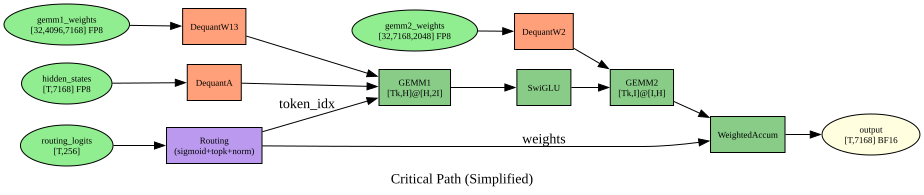

In [7]:
cp = graphviz.Digraph('CriticalPath', format='svg')
cp.attr(rankdir='LR', label='Critical Path (Simplified)', fontsize='14')
cp.attr('node', fontsize='9')

# Simplified nodes
cp.node('hs', 'hidden_states\n[T,7168] FP8', shape='ellipse', style='filled', fillcolor='lightgreen')
cp.node('w13', 'gemm1_weights\n[32,4096,7168] FP8', shape='ellipse', style='filled', fillcolor='lightgreen')
cp.node('w2', 'gemm2_weights\n[32,7168,2048] FP8', shape='ellipse', style='filled', fillcolor='lightgreen')
cp.node('rl', 'routing_logits\n[T,256]', shape='ellipse', style='filled', fillcolor='lightgreen')

cp.node('dqA', 'DequantA', shape='box', style='filled', fillcolor='lightsalmon')
cp.node('dqW13', 'DequantW13', shape='box', style='filled', fillcolor='lightsalmon')
cp.node('dqW2', 'DequantW2', shape='box', style='filled', fillcolor='lightsalmon')
cp.node('route', 'Routing\n(sigmoid+topk+norm)', shape='box', style='filled', fillcolor='#BB99EE')
cp.node('gemm1', 'GEMM1\n[Tk,H]@[H,2I]', shape='box', style='filled', fillcolor='#88CC88')
cp.node('swiglu', 'SwiGLU', shape='box', style='filled', fillcolor='#88CC88')
cp.node('gemm2', 'GEMM2\n[Tk,I]@[I,H]', shape='box', style='filled', fillcolor='#88CC88')
cp.node('accum', 'WeightedAccum', shape='box', style='filled', fillcolor='#88CC88')
cp.node('out', 'output\n[T,7168] BF16', shape='ellipse', style='filled', fillcolor='lightyellow')

cp.edge('hs', 'dqA')
cp.edge('w13', 'dqW13')
cp.edge('w2', 'dqW2')
cp.edge('rl', 'route')
cp.edge('dqA', 'gemm1')
cp.edge('dqW13', 'gemm1')
cp.edge('route', 'gemm1', label='token_idx')
cp.edge('gemm1', 'swiglu')
cp.edge('swiglu', 'gemm2')
cp.edge('dqW2', 'gemm2')
cp.edge('gemm2', 'accum')
cp.edge('route', 'accum', label='weights')
cp.edge('accum', 'out')

display(cp)

---
## Dependency-Based DAG

Same operations as above, but grouped by **data dependency chains** instead of phases.

**4 independent chains** (can execute in parallel) converge at 3 synchronization points:

| Chain | Color | Path | Needed at |
|-------|-------|------|-----------|
| A — Hidden States | Salmon | `hidden_states` + scale → DequantA → **A** | GEMM1 |
| B — GEMM1 Weights | Blue | `gemm1_weights` + scale → DequantW13 → **W13** | GEMM1 |
| C — GEMM2 Weights | Teal | `gemm2_weights` + scale → DequantW2 → **W2** | GEMM2 |
| D — Routing | Purple | `routing_logits` + bias → Sigmoid → … → **topk_idx**, **weights** | GEMM1, Accum |

Bold red convergence edges show where independent chains must synchronize.

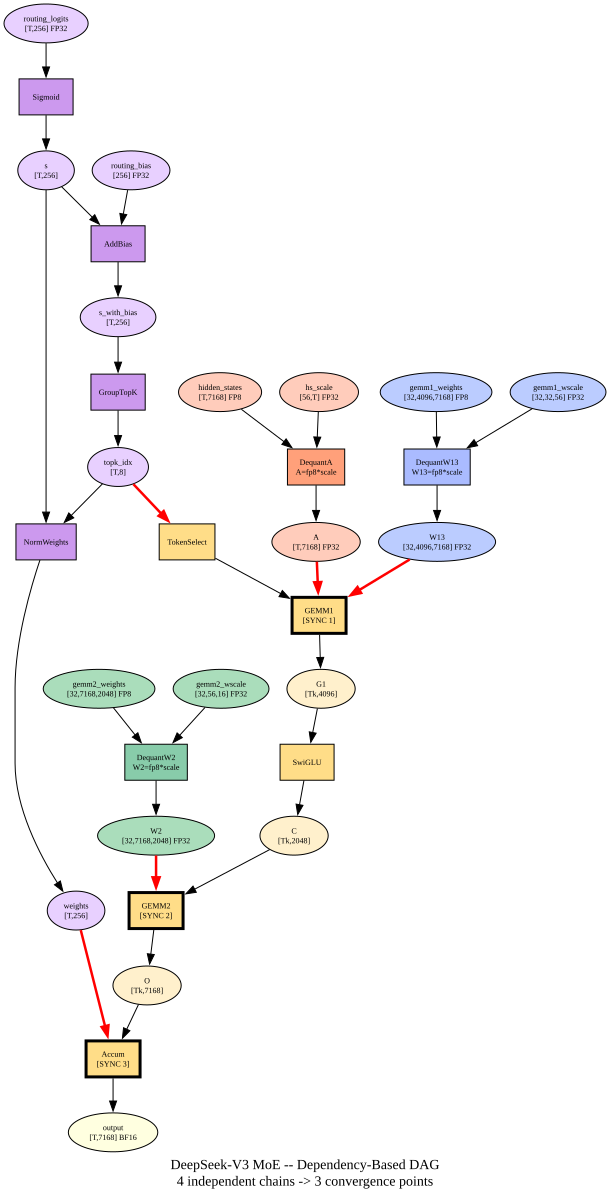

In [8]:
# Dependency-Based DAG — no clusters (avoids Windows graphviz crash)
# Chains distinguished by node color only

dep = graphviz.Digraph('DepDAG', format='svg')
dep.attr(rankdir='TB',
         label='DeepSeek-V3 MoE -- Dependency-Based DAG\n'
               '4 independent chains -> 3 convergence points',
         fontsize='14')
dep.attr('node', fontsize='8', style='filled')
dep.attr('edge', fontsize='7')

# ── Chain A: Hidden States Dequant (salmon tones) ──
dep.node('hs',   'hidden_states\n[T,7168] FP8',     shape='ellipse', fillcolor='#FFCCBB')
dep.node('hs_s', 'hs_scale\n[56,T] FP32',           shape='ellipse', fillcolor='#FFCCBB')
dep.node('DqA',  'DequantA\nA=fp8*scale',            shape='box',     fillcolor='lightsalmon')
dep.node('A',    'A\n[T,7168] FP32',                 shape='ellipse', fillcolor='#FFCCBB')
dep.edge('hs', 'DqA')
dep.edge('hs_s', 'DqA')
dep.edge('DqA', 'A')

# ── Chain B: GEMM1 Weights Dequant (blue tones) ──
dep.node('w13',   'gemm1_weights\n[32,4096,7168] FP8',  shape='ellipse', fillcolor='#BBCCFF')
dep.node('w13_s', 'gemm1_wscale\n[32,32,56] FP32',      shape='ellipse', fillcolor='#BBCCFF')
dep.node('DqW13', 'DequantW13\nW13=fp8*scale',           shape='box',     fillcolor='#AABBFF')
dep.node('W13',   'W13\n[32,4096,7168] FP32',            shape='ellipse', fillcolor='#BBCCFF')
dep.edge('w13', 'DqW13')
dep.edge('w13_s', 'DqW13')
dep.edge('DqW13', 'W13')

# ── Chain C: GEMM2 Weights Dequant (teal tones) ──
dep.node('w2',   'gemm2_weights\n[32,7168,2048] FP8',   shape='ellipse', fillcolor='#AADDBB')
dep.node('w2_s', 'gemm2_wscale\n[32,56,16] FP32',       shape='ellipse', fillcolor='#AADDBB')
dep.node('DqW2', 'DequantW2\nW2=fp8*scale',              shape='box',     fillcolor='#88CCAA')
dep.node('W2',   'W2\n[32,7168,2048] FP32',              shape='ellipse', fillcolor='#AADDBB')
dep.edge('w2', 'DqW2')
dep.edge('w2_s', 'DqW2')
dep.edge('DqW2', 'W2')

# ── Chain D: Routing (purple tones) ──
dep.node('rl',   'routing_logits\n[T,256] FP32', shape='ellipse', fillcolor='#E8D0FF')
dep.node('rb',   'routing_bias\n[256] FP32',     shape='ellipse', fillcolor='#E8D0FF')
dep.node('Sig',  'Sigmoid',                       shape='box',     fillcolor='#CC99EE')
dep.node('s',    's\n[T,256]',                     shape='ellipse', fillcolor='#E8D0FF')
dep.node('AB',   'AddBias',                        shape='box',     fillcolor='#CC99EE')
dep.node('swb',  's_with_bias\n[T,256]',           shape='ellipse', fillcolor='#E8D0FF')
dep.node('GTK',  'GroupTopK',                       shape='box',     fillcolor='#CC99EE')
dep.node('tidx', 'topk_idx\n[T,8]',               shape='ellipse', fillcolor='#E8D0FF')
dep.node('NW',   'NormWeights',                     shape='box',     fillcolor='#CC99EE')
dep.node('wts',  'weights\n[T,256]',               shape='ellipse', fillcolor='#E8D0FF')
dep.edge('rl', 'Sig')
dep.edge('Sig', 's')
dep.edge('s', 'AB')
dep.edge('rb', 'AB')
dep.edge('AB', 'swb')
dep.edge('swb', 'GTK')
dep.edge('GTK', 'tidx')
dep.edge('s', 'NW')
dep.edge('tidx', 'NW')
dep.edge('NW', 'wts')

# ── Convergence zone (yellow/gray tones) ──
dep.node('TS',  'TokenSelect',  shape='box', fillcolor='#FFDD88')
dep.node('GM1', 'GEMM1\n[SYNC 1]', shape='box', fillcolor='#FFDD88', penwidth='3')
dep.node('G1',  'G1\n[Tk,4096]',   shape='ellipse', fillcolor='#FFF0CC')
dep.node('SWG', 'SwiGLU',          shape='box', fillcolor='#FFDD88')
dep.node('C',   'C\n[Tk,2048]',    shape='ellipse', fillcolor='#FFF0CC')
dep.node('GM2', 'GEMM2\n[SYNC 2]', shape='box', fillcolor='#FFDD88', penwidth='3')
dep.node('O',   'O\n[Tk,7168]',    shape='ellipse', fillcolor='#FFF0CC')
dep.node('WA',  'Accum\n[SYNC 3]', shape='box', fillcolor='#FFDD88', penwidth='3')
dep.node('out', 'output\n[T,7168] BF16', shape='ellipse', fillcolor='lightyellow')

# ── Cross-chain convergence edges (bold red) ──
rs = {'color': 'red', 'penwidth': '2.5'}
dep.edge('tidx', 'TS',  **rs)
dep.edge('A',    'GM1', **rs)
dep.edge('W13',  'GM1', **rs)
dep.edge('W2',   'GM2', **rs)
dep.edge('wts',  'WA',  **rs)

# ── Sequential edges in convergence zone (black) ──
dep.edge('TS', 'GM1')
dep.edge('GM1', 'G1')
dep.edge('G1', 'SWG')
dep.edge('SWG', 'C')
dep.edge('C', 'GM2')
dep.edge('GM2', 'O')
dep.edge('O', 'WA')
dep.edge('WA', 'out')

display(dep)